Проектная работа. Группа 10. Обучение с учителем: SVM. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

# Метод опорных векторов - Support Vector Machines 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("X_prepared_sample.csv")

In [3]:
df.head()

,city_development_index,experience,last_new_job,training_hours,target,no_job_info,is_university_enrolled,relevent_experience_No relevent experience,city_city_10,city_city_100,...,education_level_5,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_not_stated,gender_Male,gender_Other,gender_not_stated
0,0.920,21.0,1.0,36.0,1.0,1,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0.776,15.0,5.0,47.0,0.0,0,0,True,False,False,...,False,False,False,False,False,True,False,True,False,False
2,0.624,5.0,0.0,83.0,0.0,1,1,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,0.789,0.0,0.0,52.0,1.0,0,1,True,False,False,...,False,True,False,False,False,False,False,False,False,True
4,0.767,21.0,4.0,8.0,0.0,0,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [4]:
df.target.unique()

array([1., 0.])

2 различных значения в целевой переменной
[1., 0.]

<Axes: xlabel='target', ylabel='count'>

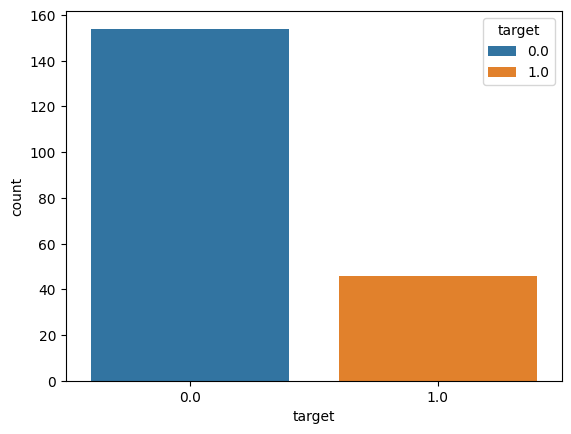

In [5]:
sns.countplot(data=df, x='target', hue='target')

In [6]:
df['target'].value_counts(normalize=True)

target
0.0    0.77
1.0    0.23
Name: proportion, dtype: float64

Дисбаланс классов примерно 25% (target=1) на 75% (target=0)

**ЗАДАНИЕ: Вычислите корреляцию между различными признаками и колонкой "quality". Чтобы сделать это, Вам можете использовать значения 0 и 1 вместо текстовых значений Legit и Fraud.**

In [7]:
target_corr = df.select_dtypes(include='number').corr()['target']
target_corr

city_development_index   -0.305343
experience               -0.108859
last_new_job             -0.016166
training_hours            0.031419
target                    1.000000
no_job_info               0.068596
is_university_enrolled    0.047791
Name: target, dtype: float64

**ЗАДАНИЕ: Нарисуйте график bar plot, отобразив значения корреляции для поддельных вин.**

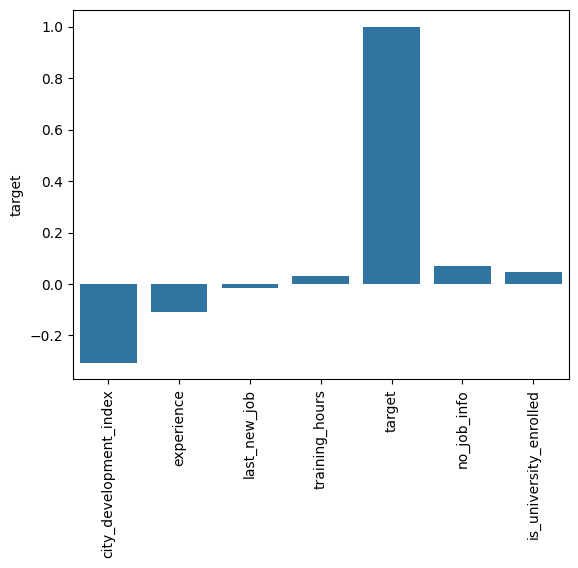

In [8]:
sns.barplot(target_corr)
plt.xticks(rotation=90)
plt.show()

Видим положительную корреляцию target=1 (оттока) c no_job_info (отсутствие прошлой работы).

Отрицательная корреляция особенно сильна с city_development_index 

**ЗАДАНИЕ: Нарисуйте график clustermap с помощью seaborn, чтобы исследовать связи между переменными.**

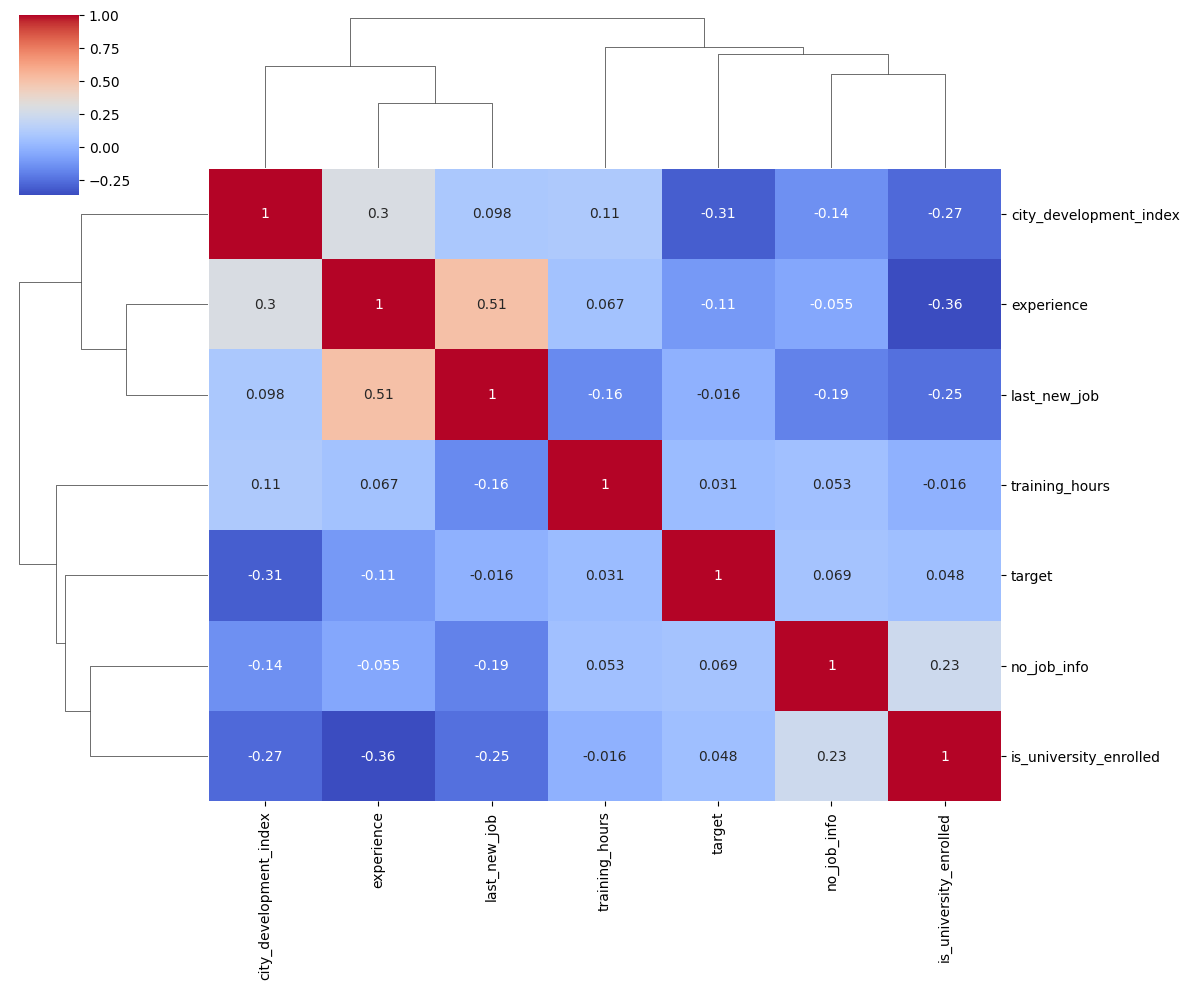

In [9]:
sns.clustermap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', figsize=(12, 10))

----
## Модель машинного обучения

In [10]:
df.dropna(inplace=True)
X,y = df.drop('target', axis=1), df['target']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC

model = SVC(class_weight='balanced')

dummy_model = DummyClassifier(strategy='stratified')

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C':[0.001, 0.01, 0.1, 0.5, 1],'gamma':['scale', 'auto']}
grid = GridSearchCV(model, param_grid, n_jobs=-1)

In [15]:
grid.fit(scaled_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_weight='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'gamma': ['scale', 'auto']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [16]:
dummy_model.fit(scaled_X_train,y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'stratified'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [17]:
grid.best_params_

{'C': 1, 'gamma': 'auto'}

**ЗАДАНИЕ: Отобразите матрицу "confusion matrix" и отчёт "classification report" для Вашей модели.**

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = grid.best_estimator_.predict(scaled_X_test)
y_pred_dummy = dummy_model.predict(scaled_X_test)

In [19]:
confusion_matrix(y_test, y_pred)

array([[29,  3],
       [ 4,  4]])

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89        32
         1.0       0.57      0.50      0.53         8

    accuracy                           0.82        40
   macro avg       0.73      0.70      0.71        40
weighted avg       0.82      0.82      0.82        40



In [21]:
print('Dummy predictions')
print(classification_report(y_test, y_pred_dummy))

Dummy predictions
              precision    recall  f1-score   support

         0.0       0.81      0.78      0.79        32
         1.0       0.22      0.25      0.24         8

    accuracy                           0.68        40
   macro avg       0.51      0.52      0.51        40
weighted avg       0.69      0.68      0.68        40



Модель правильно находит отток в половине случаев. И почти 60% оттекающих пользователей определяется. 

Модель определенно лучше случайного угадывания на основе популярности класса. И учитываю общую сложность определения оттока сотркдников выглядит хорошо